In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# Your CLASS wrappers (adapt names if needed)
from classy_NEDE import Class as Class_NEDE


plt.rcParams.update(plt.rcParamsDefault)

mpl.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["CMU Serif", "Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "axes.unicode_minus": False,
    "font.size": 18,
    "axes.labelsize": 18,
    "axes.titlesize": 18,
    "legend.fontsize": 14,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.frameon": False,
    "savefig.format": "pdf",
    "savefig.bbox": "tight",
    "xtick.top": True,
    "ytick.right": True,
})

In [2]:
zPk = 50.0      # redshift at which to compute P(k)
k_targets      = np.array([0.05, 1])  # 1/Mpc
kstr           = ",".join(str(x) for x in k_targets[::-1])

base_dict = {
        # '100*theta_s': 1.041783,
        'h': 7.288643e-01, # BF
        'omega_b': 2.313339e-02,  
        'omega_cdm': 1.353455e-01,  
        'A_s': 2.11158512e-9,  
        'n_s': 9.783335e-01,  
        #'tau_reio': 6.094734e-02,  
        'output': 'dTk, mPk, vTk', 
        'lensing': 'no',
        'N_ur': 2.0328, #NB
        'N_ncdm': 1, #NB
        'm_ncdm': 0.06, #NB
        'T_ncdm': 0.71611, #NB
        'YHe': 2.457148e-01,  
        'z_pk': zPk,
        'k_output_values': kstr,
        'P_k_max_1/Mpc': 15.0,
        'non_linear': 'hmcode',
        'k_pivot': 0.05,
}

NEDE_params = {
        'l_switch_limber': 9, #NB
        'delta_Neff_drmd': 8.289278e-01,  
        'z_stop': 10**(4.825726e+00),  
        'f_idm_drmd': 2.854793e-02, # BF
        'G_over_aH_drmd_ini': 10**(1.305733e+01),  
}

LCDM_params = {
      'delta_Neff_drmd': 0.0,
      'f_idm_drmd': 0.0,
      'G_over_aH_drmd_ini': 0.0,
}

def build_NEDE():
        cosmo = Class_NEDE()
        NEDE_dict = base_dict.copy()
        NEDE_dict.update(NEDE_params)
        cosmo.set(NEDE_dict)
        cosmo.compute()
        return cosmo

def build_LCDM():
    base = Class_NEDE()
    LCDM_dict = base_dict.copy()

    # First zero out the DRMD sector
    LCDM_dict.update(LCDM_params)

    LCDM_dict['N_ur'] += NEDE_params['delta_Neff_drmd']
    print('Updated N_ur for LCDM:', LCDM_dict['N_ur'])
    print('Set NEDE params to zero for LCDM.',
          LCDM_dict['delta_Neff_drmd'], LCDM_dict['f_idm_drmd'],
          LCDM_dict['G_over_aH_drmd_ini'])

    base.set(LCDM_dict)  
    base.compute()
    return base


cosmo_NEDE = build_NEDE()
cosmo_LCDM = build_LCDM()

print('kstring:', kstr)

Updated N_ur for LCDM: 2.8617277999999997
Set NEDE params to zero for LCDM. 0.0 0.0 0.0
kstring: 1.0,0.05


In [3]:
bg_NEDE = cosmo_NEDE.get_background()
bg_LCDM = cosmo_LCDM.get_background()

In [4]:
cosmo_NEDE.pars

{'h': 0.7288643,
 'omega_b': 0.02313339,
 'omega_cdm': 0.1353455,
 'A_s': 2.11158512e-09,
 'n_s': 0.9783335,
 'output': 'dTk, mPk, vTk',
 'lensing': 'no',
 'N_ur': 2.0328,
 'N_ncdm': 1,
 'm_ncdm': 0.06,
 'T_ncdm': 0.71611,
 'YHe': 0.2457148,
 'z_pk': 50.0,
 'k_output_values': '1.0,0.05',
 'P_k_max_1/Mpc': 15.0,
 'non_linear': 'hmcode',
 'k_pivot': 0.05,
 'l_switch_limber': 9,
 'delta_Neff_drmd': 0.8289278,
 'z_stop': 66946.21069402112,
 'f_idm_drmd': 0.02854793,
 'G_over_aH_drmd_ini': 11411165391352.252}

In [5]:
cosmo_LCDM.pars

{'h': 0.7288643,
 'omega_b': 0.02313339,
 'omega_cdm': 0.1353455,
 'A_s': 2.11158512e-09,
 'n_s': 0.9783335,
 'output': 'dTk, mPk, vTk',
 'lensing': 'no',
 'N_ur': 2.8617277999999997,
 'N_ncdm': 1,
 'm_ncdm': 0.06,
 'T_ncdm': 0.71611,
 'YHe': 0.2457148,
 'z_pk': 50.0,
 'k_output_values': '1.0,0.05',
 'P_k_max_1/Mpc': 15.0,
 'non_linear': 'hmcode',
 'k_pivot': 0.05,
 'delta_Neff_drmd': 0.0,
 'f_idm_drmd': 0.0,
 'G_over_aH_drmd_ini': 0.0}

Radiation-matter equality scale factor (NEDE): 2.933e-04
Radiation-matter equality scale factor (LCDM): 2.933e-04
100*theta_s (NEDE): 1.04347
100*theta_s (LCDM): 1.04347

--- Growth Rate at z=50.0 ---
f(z) (NEDE): 0.98857
f(z) (LCDM): 0.98857
Difference:  7.86143e-14 %


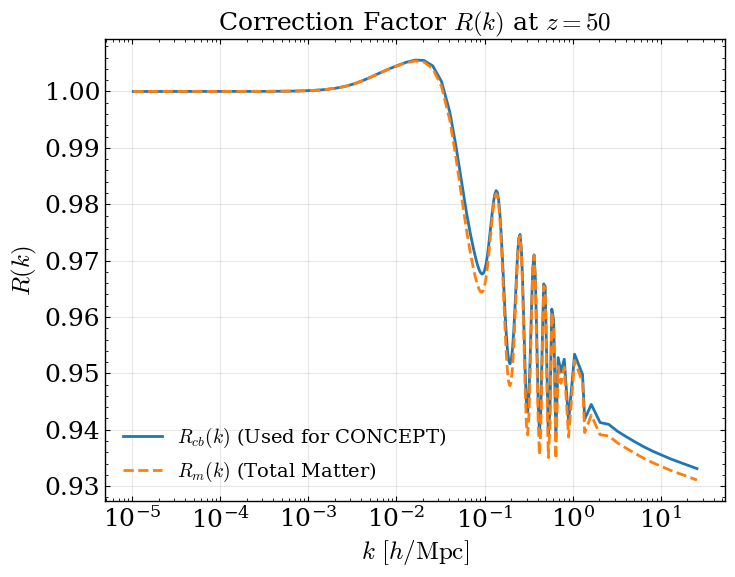

In [103]:
# Print the radiation matter equality scale factor for both models
a_eq_NEDE = cosmo_NEDE.get_current_derived_parameters(['a_eq'])
a_eq_LCDM = cosmo_LCDM.get_current_derived_parameters(['a_eq'])
theta_100_NEDE = cosmo_NEDE.get_current_derived_parameters(['100*theta_s'])
theta_100_LCDM = cosmo_LCDM.get_current_derived_parameters(['100*theta_s'])
print(f"Radiation-matter equality scale factor (NEDE): {a_eq_NEDE['a_eq']:.3e}")
print(f"Radiation-matter equality scale factor (LCDM): {a_eq_LCDM['a_eq']:.3e}")
print(f"100*theta_s (NEDE): {theta_100_NEDE['100*theta_s']:.5f}")
print(f"100*theta_s (LCDM): {theta_100_LCDM['100*theta_s']:.5f}")

# --- Check 2: Linear Growth Rate f(z) at z = 50 ---
z_init = 50.0

# Extract the scale-independent growth rate f = d ln D_+ / d ln a
f_NEDE = cosmo_NEDE.scale_independent_growth_factor_f(z_init)
f_LCDM = cosmo_LCDM.scale_independent_growth_factor_f(z_init)

print(f"\n--- Growth Rate at z={z_init} ---")
print(f"f(z) (NEDE): {f_NEDE:.5f}")
print(f"f(z) (LCDM): {f_LCDM:.5f}")
diff_f = abs(f_NEDE - f_LCDM) / f_LCDM * 100
print(f"Difference:  {diff_f:.5e} %")


# --- Check 3: Extracting Transfer Functions and Calculating R(k) ---
# Retrieve the transfer functions at the initialization redshift
tk_NEDE = cosmo_NEDE.get_transfer(z_init)
tk_LCDM = cosmo_LCDM.get_transfer(z_init)

# The k-arrays are identical if the backgrounds match perfectly
# CLASS outputs k in 1/Mpc by default in the transfer dictionary
k_tk = tk_NEDE['k (h/Mpc)'] 

# We need the physical density fractions to compute the cb-weighted transfer function
# Pulling these from your base_dict
omega_b = base_dict['omega_b']
omega_cdm = base_dict['omega_cdm']
omega_cb = omega_b + omega_cdm

# Extract total matter transfer functions (for comparison)
T_m_NEDE = tk_NEDE['d_m']
T_m_LCDM = tk_LCDM['d_m']

# Extract CDM and baryon transfer functions individually
T_c_NEDE = tk_NEDE['d_cdm']
T_b_NEDE = tk_NEDE['d_b']

T_c_LCDM = tk_LCDM['d_cdm']
T_b_LCDM = tk_LCDM['d_b']

# Calculate the cb-weighted transfer functions
T_cb_NEDE = (omega_cdm * T_c_NEDE + omega_b * T_b_NEDE) / omega_cb
T_cb_LCDM = (omega_cdm * T_c_LCDM + omega_b * T_b_LCDM) / omega_cb

# Calculate the correction factors
R_m = T_m_NEDE / T_m_LCDM
R_cb = T_cb_NEDE / T_cb_LCDM

# --- Plotting the difference between R_cb and R_m ---
fig, ax = plt.subplots(figsize=(8, 6))

ax.semilogx(k_tk, R_cb, label=r'$R_{cb}(k)$ (Used for CONCEPT)')
ax.semilogx(k_tk, R_m, '--', label=r'$R_m(k)$ (Total Matter)')

ax.set_xlabel(r'$k \ [h/\mathrm{Mpc}]$')
ax.set_ylabel(r'$R(k)$')
ax.set_title(r'Correction Factor $R(k)$ at $z=50$')
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()

In [4]:
def extract_background(cosmo, z_max=50.0):
    """Return background data (z<=z_max), including all rho_* and p_*."""
    bg = cosmo.get_background()
    print(bg.keys())

    z_all = bg['z']
    mask = z_all <= z_max

    data = {
        'z': z_all[mask],
        'a': 1 / (1 + z_all[mask]),
        'H': bg['H [1/Mpc]'][mask],
        't': bg['proper time [Gyr]'][mask],
        'rho': {},
        'p': {},
    }

    for key in bg.keys():
        if key.startswith('(.)rho_'):
            data['rho'][key] = bg[key][mask]
        elif key.startswith('(.)p_'):
            data['p'][key] = bg[key][mask]

    # Ensure sorted by a (just in case)
    order = np.argsort(data['a'])
    for k in ['z', 'a', 'H', 't']:
        data[k] = data[k][order]
    for d in (data['rho'], data['p']):
        for k in d:
            d[k] = d[k][order]

    return data


bg_NEDE = extract_background(cosmo_NEDE, z_max=50.0)
bg_LCDM = extract_background(cosmo_LCDM, z_max=50.0)

print("Available rho_ keys (NEDE):", sorted(bg_NEDE['rho'].keys()))
print("Available rho_ keys (LCDM):", sorted(bg_LCDM['rho'].keys()))
print("Available p_ keys (NEDE):", sorted(bg_NEDE['p'].keys()))
print("Available p_ keys (LCDM):", sorted(bg_LCDM['p'].keys()))

dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_idm_drmd', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_idr_drmd', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
dict_keys(['z', 'proper time [Gyr]', 'conf. time [Mpc]', 'H [1/Mpc]', 'comov. dist.', 'ang.diam.dist.', 'lum. dist.', 'comov.snd.hrz.', '(.)rho_g', '(.)rho_b', '(.)rho_cdm', '(.)rho_ncdm[0]', '(.)p_ncdm[0]', '(.)rho_lambda', '(.)rho_ur', '(.)rho_crit', '(.)rho_tot', '(.)p_tot', '(.)p_tot_prime', 'gr.fac. D', 'gr.fac. f'])
Available rho_ keys (NEDE): ['(.)rho_b', '(.)rho_cdm', '(.)rho_crit', '(.)rho_g', '(.)rho_idm_drmd', '(.)rho_idr_drmd', '(.)rho_lambda', '(.)rho_ncdm[0]', '(.)rho_tot', '(.)rho_ur']
Available rho_ keys (LCDM): ['(.)rho_b', '(.)rho_cdm', '(.)rho_crit', '(.)rho_g', '(.)rho_lambda', '(.)rho_ncdm[0]', '(.)rho_tot', '

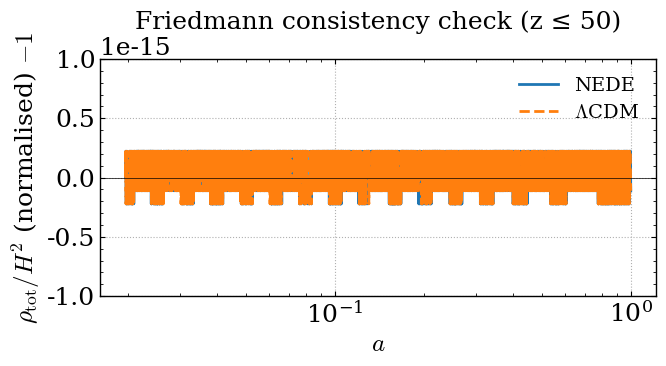

In [7]:
def compute_totals(bg_data):
    """
    Compute total rho, p, and w_tot(a).
    Prefer CLASS-provided rho_tot/p_tot if present; otherwise sum components
    (excluding crit/tot).
    """
    rho_tot = bg_data['rho']['(.)rho_tot']
    p_tot   = bg_data['p']['(.)p_tot']

    w_tot = p_tot / rho_tot
    return rho_tot, p_tot, w_tot


rho_tot_NEDE, p_tot_NEDE, w_tot_NEDE = compute_totals(bg_NEDE)
rho_tot_LCDM, p_tot_LCDM, w_tot_LCDM = compute_totals(bg_LCDM)


def friedmann_ratio(bg_data, rho_tot):
    H = bg_data['H']
    ratio = rho_tot / (H**2)
    # Normalise to 1 at the last point (a ~ 1)
    return ratio


ratio_NEDE = friedmann_ratio(bg_NEDE, rho_tot_NEDE)
ratio_LCDM = friedmann_ratio(bg_LCDM, rho_tot_LCDM)

a_NEDE = bg_NEDE['a']
a_LCDM = bg_LCDM['a']

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogx(a_NEDE, ratio_NEDE - 1.0, label="NEDE")
ax.semilogx(a_LCDM, ratio_LCDM - 1.0, '--', label=r"$\Lambda$CDM")
ax.set_ylim(-1e-15, 1e-15)

ax.set_xlabel(r"$a$")
ax.set_ylabel(r"$\rho_{\mathrm{tot}}/H^2$ (normalised) $- 1$")
ax.set_title("Friedmann consistency check (z ≤ 50)")
ax.axhline(0, color='k', lw=0.5)
ax.grid(True, ls=":")
ax.legend()
plt.tight_layout()
plt.show()

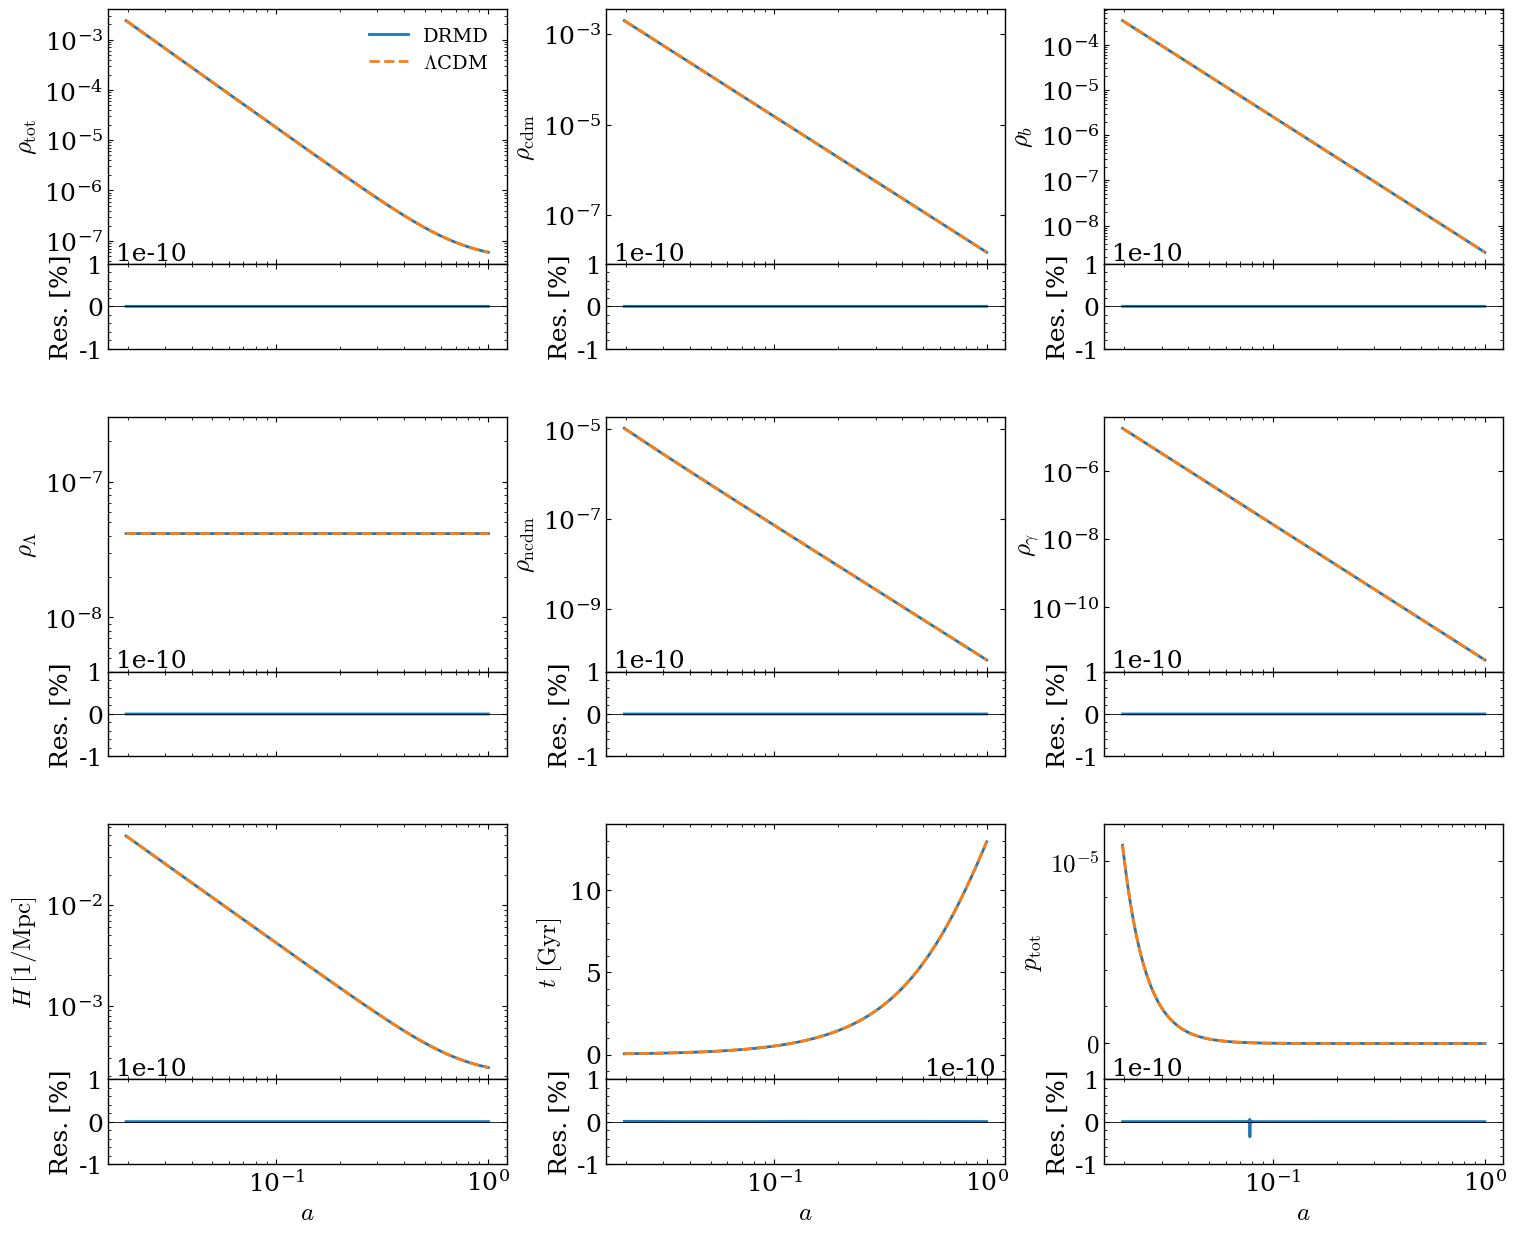

In [90]:
a_ref = bg_NEDE['a']

H_NEDE = bg_NEDE['H']
H_LCDM = bg_LCDM['H']
rho_g = bg_NEDE['rho']['(.)rho_g']
rho_ur = bg_NEDE['rho']['(.)rho_ur']
rho_idr = bg_NEDE['rho'].get('(.)rho_idr_drmd', 0.0) # Dark radiation
rho_lambda = bg_NEDE['rho']['(.)rho_lambda']
p_ncdm = bg_NEDE['p']['(.)p_ncdm[0]']

p_tot_NEDE = (rho_g + rho_ur + rho_idr) / 3.0 + p_ncdm - rho_lambda
p_tot_LCDM = bg_LCDM['p']['(.)p_tot']


t_NEDE = bg_NEDE['t']
t_LCDM = bg_LCDM['t']
rel = lambda N, L: (N - L) / L

# ---- Pick 9 components in order for a 3x3 grid ----
keys = [
    "(.)rho_tot",     "(.)rho_cdm",     "(.)rho_b",
    "(.)rho_lambda",  "(.)rho_ncdm[0]", "(.)rho_g",
    "H",              "t",              "(.)p_tot"
]

ylabel_map = {
    "(.)rho_b"     : r"$\rho_b$",
    "(.)rho_cdm"   : r"$\rho_{\rm cdm}$",
    "(.)rho_lambda": r"$\rho_\Lambda$",
    "(.)rho_g"     : r"$\rho_\gamma$",
    "(.)rho_ncdm[0]": r"$\rho_{\rm ncdm}$",
    "(.)rho_tot"   : r"$\rho_{\rm tot}$",
    "(.)rho_ur"    : r"$\rho_{\rm ur}$",
    "(.)p_tot"     : r"$p_{\rm tot}$", 
    "H"            : r"$H\;[1/\mathrm{Mpc}]$",
    "t"            : r"$t\;[\mathrm{Gyr}]$"
}

# Helper function to dynamically find if a key is in "rho", "p", or the top-level dict
def get_bg_array(bg_dict, key):
    if "rho" in bg_dict and key in bg_dict["rho"]:
        return bg_dict["rho"][key]
    elif "p" in bg_dict and key in bg_dict["p"]:
        return bg_dict["p"][key]
    elif key in bg_dict:
        return bg_dict[key]
    else:
        raise KeyError(f"Could not find '{key}' in the background data.")

# ---- Figure: 3 block-rows, 3 columns ----
fig = plt.figure(figsize=(18, 15)) 
outer = fig.add_gridspec(
    nrows=3, ncols=3,
    hspace=0.20,   # Space BETWEEN species blocks
    wspace=0.25
)

for idx, key in enumerate(keys):
    r = idx // 3          # 0, 1, 2
    c = idx % 3           # 0, 1, 2

    # Each block is a 2-row subgridspec: main + residual
    sub = outer[r, c].subgridspec(
        nrows=2, ncols=1,
        height_ratios=[3, 1],
        hspace=0.0        # NO space between main and residual
    )

    ax_main = fig.add_subplot(sub[0, 0])
    ax_res  = fig.add_subplot(sub[1, 0], sharex=ax_main)

    # --- Extract appropriate data based on the key ---
    if key == "H":
        valN = H_NEDE
        valL = H_LCDM
        ax_main.loglog(a_ref, valN, label="DRMD")
        ax_main.loglog(a_ref, valL, "--", label=r"$\Lambda$CDM")
        
    elif key == "t":
        valN = t_NEDE
        valL = t_LCDM
        ax_main.semilogx(a_ref, valN, label="DRMD")
        ax_main.semilogx(a_ref, valL, "--", label=r"$\Lambda$CDM")

    elif key == "(.)p_tot":
        valN = p_tot_NEDE
        valL = p_tot_LCDM
        ax_main.semilogx(a_ref, valN, label="DRMD")
        ax_main.semilogx(a_ref, valL, "--", label=r"$\Lambda$CDM")
        
        # Set exact tick locations
        ax_main.set_yticks([-1e-5, 0, 1e-5])
        
        # Manually overwrite the labels with LaTeX formatting
        ax_main.set_yticklabels([r'$-10^{-5}$', r'$0$', r'$10^{-5}$'])
        
        ax_main.set_ylim(-0.2e-5, 1.2e-5)
        
    else:
        # Density and pressure components
        raw_valN = get_bg_array(bg_NEDE, key).copy()
        raw_valL = get_bg_array(bg_LCDM, key)
        
        # Add DRMD specific adjustments if we are dealing with CDM/UR
        if key == "(.)rho_cdm" and "rho" in bg_NEDE:
            raw_valN = raw_valN + bg_NEDE["rho"].get("(.)rho_idm_drmd", 0.0)
        if key == "(.)rho_ur" and "rho" in bg_NEDE:
            raw_valN = raw_valN + bg_NEDE["rho"].get("(.)rho_idr_drmd", 0.0)

        valN = raw_valN
        valL = np.interp(a_ref, bg_LCDM["a"], raw_valL)
        ax_main.loglog(a_ref, valN, label="DRMD")   
        ax_main.loglog(a_ref, valL, "--", label=r"$\Lambda$CDM")
        
        if key == '(.)rho_tot':
            ax_main.legend(loc="upper right", frameon=False)
        if key == "(.)rho_lambda":
            ax_main.set_yticks([1e-8, 1e-7])
            ax_main.set_ylim(4e-9, 3e-7)

    # ===== Main Panel Formatting =====
    ax_main.set_ylabel(ylabel_map.get(key, key))
    ax_main.tick_params(labelbottom=False)

    # ===== Residual Panel Formatting =====
    # Avoid division by zero in residuals if valL crosses exactly 0
    with np.errstate(divide='ignore', invalid='ignore'):
        residual = 100 * rel(valN, valL)
        
    ax_res.semilogx(a_ref, residual)
    ax_res.axhline(0, color="k", lw=0.6)
    ax_res.set_ylabel(r"Res. [%]")
    
    # Force the strict limits on the residual plots
    ax_res.set_ylim(-1e-10, 1e-10)

    # Only bottom row (r == 2) gets an x-label in a 3x3 grid
    if r == 2:
        ax_res.set_xlabel(r"$a$")
    else:
        ax_res.tick_params(labelbottom=False)


    offset_text = ax_res.yaxis.get_offset_text()
    offset_text.set_position((0.02, 0.0))

    # Handle the offset text specifically for t(a)
    if key == "t":
        # Render the figure once to populate tick offsets before moving them
        fig.canvas.draw()
        offset_text = ax_res.yaxis.get_offset_text()
        offset_text.set_position((0.80, 0.0))
        ax_main.set_ylim(-1.5, 14)  # Looser limits for t(a)

    if key == "(.)rho_g":
        # Fix the y label position for better such that it doesnt overlap with the rho_ncdm plot
        ax_main.yaxis.set_label_coords(-0.16, 0.5)

fig.savefig('background_matching.pdf', bbox_inches='tight')
plt.show()

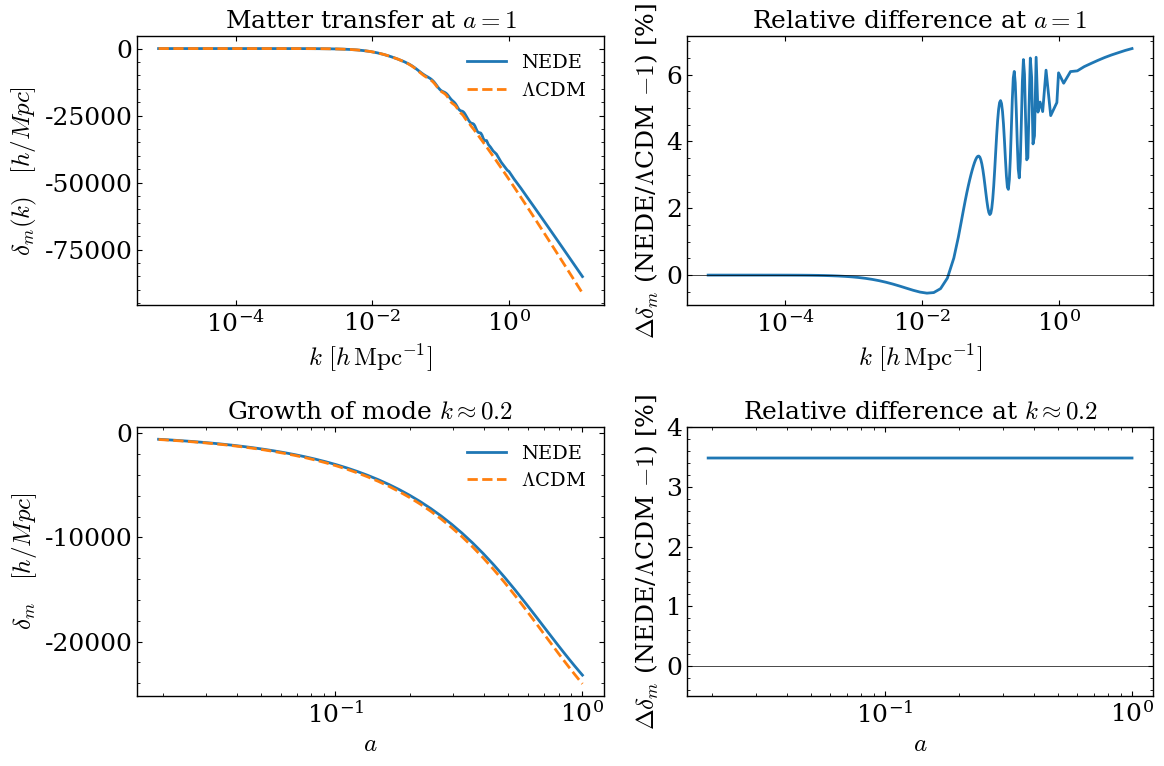

In [ ]:
# --- Get transfer tables and k,z grids ---
tr_NEDE, k_NEDE, z_NEDE = cosmo_NEDE.get_transfer_and_k_and_z()
tr_LCDM, k_LCDM, z_LCDM = cosmo_LCDM.get_transfer_and_k_and_z()


d_m_NEDE = tr_NEDE['d_m']   # shape (N_k, N_z)
d_m_LCDM = tr_LCDM['d_m']

a_NEDE = 1.0 / (1.0 + z_NEDE)
a_LCDM = 1.0 / (1.0 + z_LCDM)

# --- 1) δ_m(k) at a = 1 (z = 0) ---

z_target = 0.0
iz_NEDE = np.argmin(np.abs(z_NEDE - z_target))
iz_LCDM = np.argmin(np.abs(z_LCDM - z_target))

d_m_NEDE_z0 = d_m_NEDE[:, iz_NEDE]      # function of k
d_m_LCDM_z0 = d_m_LCDM[:, iz_LCDM]


# --- 2) δ_m(a) at k ≈ 0.05 h/Mpc ---

k_target = 0.2  # h/Mpc
ik_NEDE = np.argmin(np.abs(k_NEDE - k_target))
ik_LCDM = np.argmin(np.abs(k_LCDM - k_target))

k_used_NEDE = k_NEDE[ik_NEDE]

d_m_NEDE_kfix = d_m_NEDE[ik_NEDE, :]   # function of z (→ a)
d_m_LCDM_kfix = d_m_LCDM[ik_LCDM, :]

# --- Make plots ---

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Top-left: δ_m(k) at a=1
ax[0, 0].semilogx(k_NEDE, d_m_NEDE_z0, label='NEDE')
ax[0, 0].semilogx(k_NEDE, d_m_LCDM_z0, '--', label=r'$\Lambda$CDM')
ax[0, 0].set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$')
ax[0, 0].set_ylabel(r'$\delta_m(k)\quad [h/Mpc]$')
ax[0, 0].set_title(r'Matter transfer at $a=1$')
ax[0, 0].legend()

# Top-right: fractional difference vs k at a=1
ax[0, 1].semilogx(k_NEDE, -100 * (d_m_NEDE_z0 / d_m_LCDM_z0 - 1.0))
ax[0, 1].set_xlabel(r'$k\ [h\,{\rm Mpc}^{-1}]$')
ax[0, 1].set_ylabel(r'$\Delta\delta_m$ (NEDE/$\Lambda$CDM $-1$) [%]')
ax[0, 1].set_title(r'Relative difference at $a=1$')
ax[0, 1].axhline(0, color='k', lw=0.5)

# Bottom-left: δ_m(a) at k≈0.05
ax[1, 0].semilogx(a_NEDE, d_m_NEDE_kfix, label='NEDE')
ax[1, 0].semilogx(a_NEDE, d_m_LCDM_kfix, '--', label=r'$\Lambda$CDM')
ax[1, 0].set_xlabel(r'$a$')
ax[1, 0].set_ylabel(r'$\delta_m\quad [h/Mpc]$')
ax[1, 0].set_title(r'Growth of mode $k\approx{0.2}$')
ax[1, 0].legend()

# Bottom-right: fractional difference vs a at k≈0.05
ax[1, 1].semilogx(a_NEDE, -100 * (d_m_NEDE_kfix / d_m_LCDM_kfix - 1))
ax[1, 1].set_xlabel(r'$a$')
ax[1, 1].set_ylabel(r'$\Delta\delta_m$ (NEDE/$\Lambda$CDM $-1$) [%]')
ax[1, 1].set_title(r'Relative difference at $k\approx{0.2}$')
ax[1, 1].axhline(0, color='k', lw=0.5)
ax[1, 1].set_ylim(-0.5, 4)

plt.tight_layout()
plt.show()